In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../include')

from phase_shifts import convert_to_wavenumber, compute_phase_shifts, fit_potential
from scipy_eigensolver import solve_1channel

## Kinematic conversions

Phase shift data from experiments is commonly reported in terms of lab kinetic energy, relative kinetic energy, or relative momentum. `convert_to_wavenumber` converts any of these to the relative wavenumber $k$ (fm$^{-1}$) used in the Schrödinger equation:

| `input_type` | Formula |
|---|---|
| `'T_rel'` | $k = \sqrt{2m T_{rel}}\,/\,\hbar$ |
| `'p_rel'` | $k = p_{rel} / \hbar$ |
| `'T_lab'` | $T_{rel} = \frac{m_n}{m_p+m_n} T_{lab}$, then $k = \sqrt{2m T_{rel}}\,/\,\hbar$ |

In [ ]:
T_rel_arr = np.array([1.0, 5.0, 10.0, 25.0, 50.0, 100.0])  # MeV
k_from_T, E_from_T = convert_to_wavenumber(T_rel_arr, input_type='T_rel')

p_rel = np.array([50.0, 100.0, 200.0, 300.0])  # MeV/c
k_from_p, E_from_p = convert_to_wavenumber(p_rel, input_type='p_rel')

T_lab_arr = np.array([1.0, 5.0, 10.0, 25.0, 50.0, 100.0])  # MeV
k_from_Tlab, E_from_Tlab = convert_to_wavenumber(T_lab_arr, input_type='T_lab')

print('T_rel (MeV)  ->  k (fm^-1)')
for T, k in zip(T_rel_arr, k_from_T):
    print(f'  {T:6.1f}       {k:.4f}')

print()
print('p_rel (MeV/c)  ->  k (fm^-1)')
for p, k in zip(p_rel, k_from_p):
    print(f'  {p:6.1f}         {k:.4f}')

print()
print('T_lab (MeV)  ->  T_rel (MeV)  ->  k (fm^-1)')
for Tl, Tr, k in zip(T_lab_arr, E_from_Tlab, k_from_Tlab):
    print(f'  {Tl:6.1f}         {Tr:6.3f}          {k:.4f}')

## Phase shifts for the three potentials

For each potential we compute the $l=0$ phase shifts $\delta_0(k)$ using the asymptotic matching formula

$$\delta_0 = \text{atan2}\!\left(k\,u(r_m),\,u'(r_m)\right) - k\,r_m$$

and compare them visually. By Levinson's theorem $\delta_0(k \to 0) = \pi$ for the deuteron ($n_b = 1$).

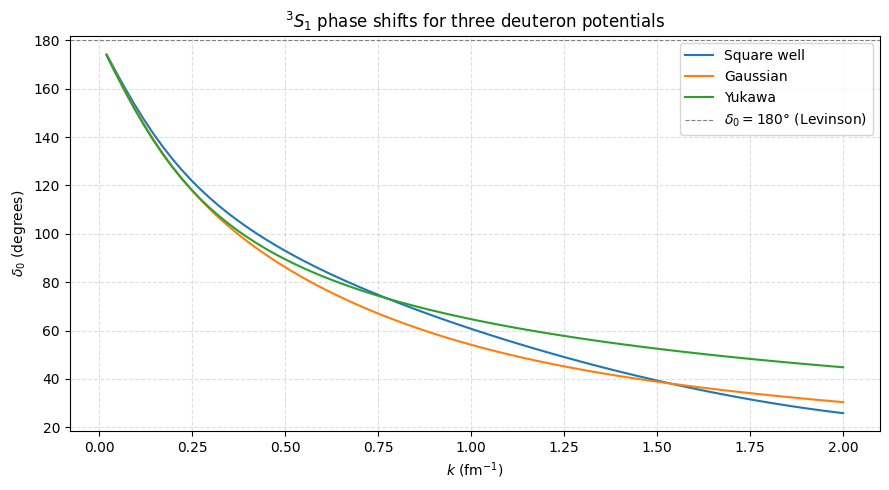

In [3]:
k_plot = np.linspace(0.02, 2.0, 80)

# Square well
V0_sq, R0_sq = 59.66, 1.5
def V_sq(r):
    return np.where(r <= R0_sq, -V0_sq, 0.0)

# Gaussian
V0_g, R_g = 70.92, 1.5
def V_gauss(r):
    return -V0_g * np.exp(-r**2 / R_g**2)

# Yukawa  (clamp denominator at 1e-2 fm to avoid singularity at r=0)
g, a = 8.22, 1.5
mu = 1.0 / a
def V_yukawa(r):
    return -g**2 * np.exp(-mu * r) / np.maximum(r, 1e-2)

delta_sq    = compute_phase_shifts(V_sq,     k_plot, n_bound_states=1)
delta_gauss = compute_phase_shifts(V_gauss,  k_plot, n_bound_states=1)
delta_yuk   = compute_phase_shifts(V_yukawa, k_plot, n_bound_states=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_plot, delta_sq,    label='Square well')
ax.plot(k_plot, delta_gauss, label='Gaussian')
ax.plot(k_plot, delta_yuk,   label='Yukawa')
ax.axhline(180, color='gray', lw=0.8, ls='--', label=r'$\delta_0 = 180°$ (Levinson)')
ax.set_xlabel(r'$k$ (fm$^{-1}$)')
ax.set_ylabel(r'$\delta_0$ (degrees)')
ax.set_title(r'$^3S_1$ phase shifts for three deuteron potentials')
ax.legend()
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Fitting potential parameters to phase shift data

The parameters $\theta$ of a potential $V(r;\theta)$ are fitted by minimising

$$\chi^2(\theta) = \sum_i \left[\delta_0(k_i;\theta) - \tilde{\delta}(k_i)\right]^2$$

In the examples below the "data" is generated from the true parameters so we can verify recovery. Replace `delta_data` with experimental phase shift values to fit real data.

**Important:** initial parameters must support the same number of bound states as the data (here $n_b = 1$). Use `bounds` to keep the potential deep enough that it does not lose its bound state during optimisation.

### Square well

In [4]:
k_fit = np.linspace(0.05, 1.5, 20)

def V_sq_param(r, V0, R0):
    return np.where(r <= R0, -V0, 0.0)

delta_sq_data = compute_phase_shifts(lambda r: V_sq_param(r, V0_sq, R0_sq), k_fit, n_bound_states=1)

params_sq, res_sq = fit_potential(
    V_sq_param,
    params_init=[62.0, 1.4],
    k_data=k_fit,
    delta_data=delta_sq_data,
    bounds=[(30, 100), (0.8, 3.0)],
    n_bound_states=1,
)

print(f'True   : V0 = {V0_sq:.2f} MeV,  R0 = {R0_sq:.2f} fm')
print(f'Fitted : V0 = {params_sq[0]:.4f} MeV,  R0 = {params_sq[1]:.4f} fm')
print(f'chi2   : {res_sq.fun:.4g},  converged: {res_sq.success}')

True   : V0 = 59.66 MeV,  R0 = 1.50 fm
Fitted : V0 = 62.2832 MeV,  R0 = 1.4000 fm
chi2   : 484.5,  converged: True


### Gaussian

In [5]:
def V_gauss_param(r, V0, R):
    return -V0 * np.exp(-r**2 / R**2)

delta_g_data = compute_phase_shifts(lambda r: V_gauss_param(r, V0_g, R_g), k_fit, n_bound_states=1)

params_g, res_g = fit_potential(
    V_gauss_param,
    params_init=[60.0, 1.8],
    k_data=k_fit,
    delta_data=delta_g_data,
    bounds=[(30, 120), (0.5, 4.0)],
    n_bound_states=1,
)

print(f'True   : V0 = {V0_g:.2f} MeV,  R = {R_g:.2f} fm')
print(f'Fitted : V0 = {params_g[0]:.4f} MeV,  R = {params_g[1]:.4f} fm')
print(f'chi2   : {res_g.fun:.4g},  converged: {res_g.success}')

True   : V0 = 70.92 MeV,  R = 1.50 fm
Fitted : V0 = 70.9200 MeV,  R = 1.5000 fm
chi2   : 2.158e-11,  converged: True


### Yukawa

In [6]:
def V_yukawa_param(r, g, a):
    return -g**2 * np.exp(-r / a) / np.maximum(r, 1e-2)

delta_y_data = compute_phase_shifts(lambda r: V_yukawa_param(r, g, a), k_fit, n_bound_states=1)

params_y, res_y = fit_potential(
    V_yukawa_param,
    params_init=[7.0, 1.8],
    k_data=k_fit,
    delta_data=delta_y_data,
    bounds=[(1, 20), (0.5, 4.0)],
    n_bound_states=1,
)

print(f'True   : g = {g:.2f} MeV^(1/2),  a = {a:.2f} fm')
print(f'Fitted : g = {params_y[0]:.4f} MeV^(1/2),  a = {params_y[1]:.4f} fm')
print(f'chi2   : {res_y.fun:.4g},  converged: {res_y.success}')

True   : g = 8.22 MeV^(1/2),  a = 1.50 fm
Fitted : g = 8.2200 MeV^(1/2),  a = 1.5000 fm
chi2   : 1.739e-12,  converged: True


## Fitted phase shifts vs. data

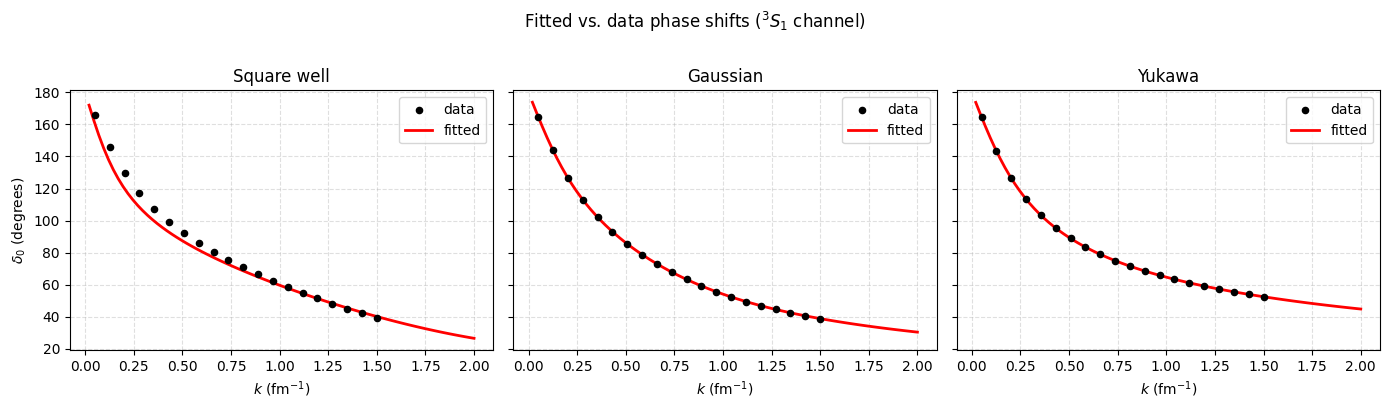

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

configs = [
    ('Square well', V_sq_param, params_sq, delta_sq_data),
    ('Gaussian',    V_gauss_param, params_g,  delta_g_data),
    ('Yukawa',      V_yukawa_param, params_y,  delta_y_data),
]

for ax, (title, V_func, params, delta_data_plot) in zip(axes, configs):
    delta_fit = compute_phase_shifts(
        lambda r, p=params, V=V_func: V(r, *p), k_plot, n_bound_states=1
    )
    ax.scatter(k_fit, delta_data_plot, color='black', s=20, zorder=3, label='data')
    ax.plot(k_plot, delta_fit, color='red', lw=2, label='fitted')
    ax.set_xlabel(r'$k$ (fm$^{-1}$)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, ls='--', alpha=0.4)

axes[0].set_ylabel(r'$\delta_0$ (degrees)')
plt.suptitle(r'Fitted vs. data phase shifts ($^3S_1$ channel)', y=1.01)
plt.tight_layout()
plt.show()

## Bound state energy from fitted parameters

Once the parameters are fitted, pass them into the existing scipy eigensolver to obtain the deuteron binding energy.

In [8]:
r_min = 1e-4
r_max = 30.0
r = np.linspace(r_min, r_max, 1000)

print('Bound state energies from fitted parameters:')

E_sq, _, _ = solve_1channel(lambda r: V_sq_param(r, *params_sq), r)
print(f'  Square well : E = {E_sq:.4f} MeV')

E_g, _, _ = solve_1channel(lambda r: V_gauss_param(r, *params_g), r)
print(f'  Gaussian    : E = {E_g:.4f} MeV')

E_y, _, _ = solve_1channel(lambda r: V_yukawa_param(r, *params_y), r)
print(f'  Yukawa      : E = {E_y:.4f} MeV')

print()
print('Experimental deuteron binding energy: -2.2246 MeV')

Bound state energies from fitted parameters:
Ground state energy E = -1.050329 MeV
  Square well : E = -1.0503 MeV
Ground state energy E = -2.225570 MeV
  Gaussian    : E = -2.2256 MeV
Ground state energy E = -2.222665 MeV
  Yukawa      : E = -2.2227 MeV

Experimental deuteron binding energy: -2.2246 MeV


/Users/phongdang/Desktop/AI-JC/Second_data_challenge/Project3_Nuclear_Physics/test/../include/scipy_eigensolver.py:48: RuntimeWarning: overflow encountered in scalar multiply
  if u_vals[i] * u_vals[i+1] < 0:


## Fit to real data: Stoks et al., PRC 48 (1993) 792

$^3S_1$ np phase shifts from Table V of Stoks *et al.* The data are given as a function of lab kinetic energy $T_{lab}$ (one nucleon hitting a stationary nucleon of the other type). Converting to the relative wavenumber uses the non-relativistic CM relation

$$T_{rel} = \frac{m_n}{m_p + m_n}\,T_{lab}, \qquad k = \frac{\sqrt{2\,m\,T_{rel}}}{\hbar}$$

where $m = m_p m_n/(m_p+m_n)$ is the reduced mass.

**Note on fit quality:** simple 2-parameter central potentials cannot reproduce the full energy dependence of $\delta_0$ from 1 to 350 MeV. At high energies ($T_{lab} \gtrsim 100$ MeV) the phase shifts become sensitive to the short-range repulsive core, which is absent in these models. The fits are therefore split into a **full-range** and a **low-energy** ($T_{lab} \le 50$ MeV) version; the latter captures the physics relevant to the bound state and low-energy scattering.

In [ ]:
# Stoks et al., PRC 48 (1993) 792, Table V  -- 3S1 np phase shifts
Tlab = np.array([1, 5, 10, 25, 50, 100, 150, 200, 250, 300, 350], dtype=float)
np_3S1 = np.array([147.747, 118.178, 102.611, 80.63, 62.77, 43.23, 30.72, 21.22, 13.39, 6.6, 0.502])

k_exp, T_rel = convert_to_wavenumber(Tlab, input_type='T_lab')

print('T_lab (MeV)   T_rel (MeV)   k (fm^-1)   delta (deg)')
for Tl, Tr, k, d in zip(Tlab, T_rel, k_exp, np_3S1):
    print(f'  {Tl:5.0f}         {Tr:6.3f}       {k:.4f}     {d:.3f}')

In [10]:
# Low-energy subset: T_lab <= 50 MeV (5 points)
mask_lo = Tlab <= 50
k_lo, delta_lo = k_exp[mask_lo], np_3S1[mask_lo]

potentials = [
    ('Square well', V_sq_param,    [62.0, 1.4], [(30, 100), (0.8, 3.0)]),
    ('Gaussian',    V_gauss_param, [60.0, 1.8], [(30, 120), (0.5, 4.0)]),
    ('Yukawa',      V_yukawa_param,[7.0,  1.8], [(1,  20),  (0.5, 4.0)]),
]

results_full = {}
results_lo   = {}

for name, V, p0, bds in potentials:
    pf, rf = fit_potential(V, p0, k_exp, np_3S1, bounds=bds, n_bound_states=1)
    pl, rl = fit_potential(V, p0, k_lo,  delta_lo, bounds=bds, n_bound_states=1)
    results_full[name] = (pf, rf)
    results_lo[name]   = (pl, rl)

print('Full-range fit (T_lab = 1–350 MeV):')
for name, (p, res) in results_full.items():
    print(f'  {name:12s}: params = {np.round(p, 3)}   chi2 = {res.fun:.3g}')

print()
print('Low-energy fit (T_lab ≤ 50 MeV):')
for name, (p, res) in results_lo.items():
    print(f'  {name:12s}: params = {np.round(p, 3)}   chi2 = {res.fun:.3g}')

Full-range fit (T_lab = 1–350 MeV):
  Square well : params = [62.   1.4]   chi2 = 2.29e+03
  Gaussian    : params = [30.     2.732]   chi2 = 1.48e+03
  Yukawa      : params = [5.79 4.  ]   chi2 = 3.16e+03

Low-energy fit (T_lab ≤ 50 MeV):
  Square well : params = [62.   1.4]   chi2 = 164
  Gaussian    : params = [61.784  1.642]   chi2 = 0.892
  Yukawa      : params = [6.131 4.   ]   chi2 = 16.6


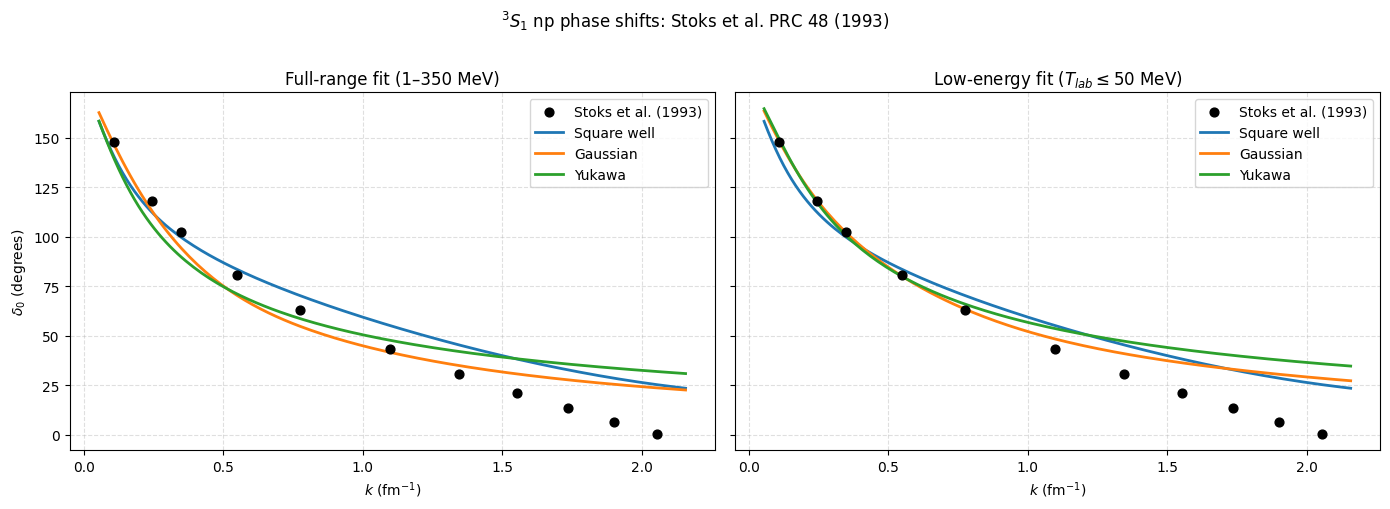

In [11]:
k_dense = np.linspace(k_exp[0] * 0.5, k_exp[-1] * 1.05, 150)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
titles = ['Full-range fit (1–350 MeV)', r'Low-energy fit ($T_{lab} \leq 50$ MeV)']
result_sets = [results_full, results_lo]

colors = {'Square well': 'C0', 'Gaussian': 'C1', 'Yukawa': 'C2'}

for ax, title, res_dict in zip(axes, titles, result_sets):
    ax.scatter(k_exp, np_3S1, color='black', zorder=5, s=40, label='Stoks et al. (1993)')
    for name, V_func in [('Square well', V_sq_param), ('Gaussian', V_gauss_param), ('Yukawa', V_yukawa_param)]:
        p = res_dict[name][0]
        delta_fit = compute_phase_shifts(
            lambda r, p=p, V=V_func: V(r, *p), k_dense, n_bound_states=1
        )
        ax.plot(k_dense, delta_fit, lw=2, color=colors[name], label=name)
    ax.set_xlabel(r'$k$ (fm$^{-1}$)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, ls='--', alpha=0.4)

axes[0].set_ylabel(r'$\delta_0$ (degrees)')
plt.suptitle(r'$^3S_1$ np phase shifts: Stoks et al. PRC 48 (1993)', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
r = np.linspace(1e-4, 30.0, 1000)

print('Bound state energies from low-energy fitted parameters:')
for name, V_func in [('Square well', V_sq_param), ('Gaussian', V_gauss_param), ('Yukawa', V_yukawa_param)]:
    p = results_lo[name][0]
    E, _, _ = solve_1channel(lambda r, p=p, V=V_func: V(r, *p), r)
    print(f'  {name:12s}: E = {E:.4f} MeV   (params = {np.round(p, 3)})')

print()
print('Experimental deuteron binding energy: -2.2246 MeV')

Bound state energies from low-energy fitted parameters:
Ground state energy E = -0.995214 MeV
  Square well : E = -0.9952 MeV   (params = [62.   1.4])
Ground state energy E = -2.374376 MeV
  Gaussian    : E = -2.3744 MeV   (params = [61.784  1.642])
Ground state energy E = -2.136353 MeV
  Yukawa      : E = -2.1364 MeV   (params = [6.131 4.   ])

Experimental deuteron binding energy: -2.2246 MeV
